# Priprema i vizualuzacija značajki

### Uzet skup 2026 - 03 - 01 - 23, fuel_data_csv

Učitavanje + split stupaca

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)

path = "../data/FuelData/2026-02-01-28/fuel_data.csv"  # prilagodi po potrebi

raw = pd.read_csv(path, sep=";")

print(raw.shape)
print(raw.columns)
raw.head()

(327420, 8)
Index(['obj_id', 'time', 'fuel_lvl', 'withdrawl_flag', 'speed',
       'contact_value', 'gps_latitude', 'gps_longitude'],
      dtype='object')


,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
0,4760,2026-02-15 19:37:00.000,97,0,0,-,"46,396395","16,449953"
1,4760,2026-02-15 19:38:00.000,97,0,0,-,"46,396391","16,449958"
2,4760,2026-02-15 19:39:00.000,97,0,0,-,"46,396387","16,449959"
3,4760,2026-02-15 19:40:00.000,97,0,0,-,"46,396387","16,44996"
4,4760,2026-02-15 19:41:00.000,97,0,0,-,"46,396387","16,449961"


Prikaz podataka

In [7]:
df = raw.copy()
df.rename(columns={"withdrawl_flag": "withdrawal_flag"}, inplace=True)
df.head()

,obj_id,time,fuel_lvl,withdrawal_flag,speed,contact_value,gps_latitude,gps_longitude
0,4760,2026-02-15 19:37:00.000,97,0,0,-,"46,396395","16,449953"
1,4760,2026-02-15 19:38:00.000,97,0,0,-,"46,396391","16,449958"
2,4760,2026-02-15 19:39:00.000,97,0,0,-,"46,396387","16,449959"
3,4760,2026-02-15 19:40:00.000,97,0,0,-,"46,396387","16,44996"
4,4760,2026-02-15 19:41:00.000,97,0,0,-,"46,396387","16,449961"


Pretvorba tipova + osnovno čišćenje

In [8]:
# vrijeme u datetime
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# numerički stupci
num_cols = ["fuel_lvl", "speed", "gps_latitude", "gps_longitude"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# withdrawal_flag i contact_value kao int
df["withdrawal_flag"] = pd.to_numeric(df["withdrawal_flag"], errors="coerce").fillna(0).astype(int)
df["contact_value"] = pd.to_numeric(df["contact_value"], errors="coerce").fillna(0).astype(int)

# makni redove bez vremena ili fuel_lvl
df = df.dropna(subset=["time", "fuel_lvl"])

df.dtypes

obj_id                      int64
time               datetime64[ns]
fuel_lvl                    int64
withdrawal_flag             int64
speed                       int64
contact_value               int64
gps_latitude              float64
gps_longitude             float64
dtype: object

Pregled

In [9]:
df.describe()
df.head()

,obj_id,time,fuel_lvl,withdrawal_flag,speed,contact_value,gps_latitude,gps_longitude
0,4760,2026-02-15 19:37:00,97,0,0,0,NaN,NaN
1,4760,2026-02-15 19:38:00,97,0,0,0,NaN,NaN
2,4760,2026-02-15 19:39:00,97,0,0,0,NaN,NaN
3,4760,2026-02-15 19:40:00,97,0,0,0,NaN,NaN
4,4760,2026-02-15 19:41:00,97,0,0,0,NaN,NaN


Kreiranje ključne značajke: delta_fuel

In [15]:
# sortiranje po vozilu i vremenu
df = df.sort_values(["obj_id", "time"])

# prethodna razina goriva po vozilu
df["fuel_lvl_prev"] = df.groupby("obj_id")["fuel_lvl"].shift(1)

# promjena goriva
df["delta_fuel"] = df["fuel_lvl"] - df["fuel_lvl_prev"]

df[["obj_id", "time", "fuel_lvl", "fuel_lvl_prev", "delta_fuel"]].head(10)

,obj_id,time,fuel_lvl,fuel_lvl_prev,delta_fuel
0,4760,2026-02-15 19:37:00,97,NaN,NaN
1,4760,2026-02-15 19:38:00,97,97.0,0.0
2,4760,2026-02-15 19:39:00,97,97.0,0.0
3,4760,2026-02-15 19:40:00,97,97.0,0.0
4,4760,2026-02-15 19:41:00,97,97.0,0.0
5,4760,2026-02-15 19:42:00,97,97.0,0.0
6,4760,2026-02-15 19:43:00,97,97.0,0.0
7,4760,2026-02-15 19:44:00,97,97.0,0.0
8,4760,2026-02-15 19:45:00,97,97.0,0.0
9,4760,2026-02-15 19:46:00,97,97.0,0.0


Vizualizacija distribucije delta_fuel:

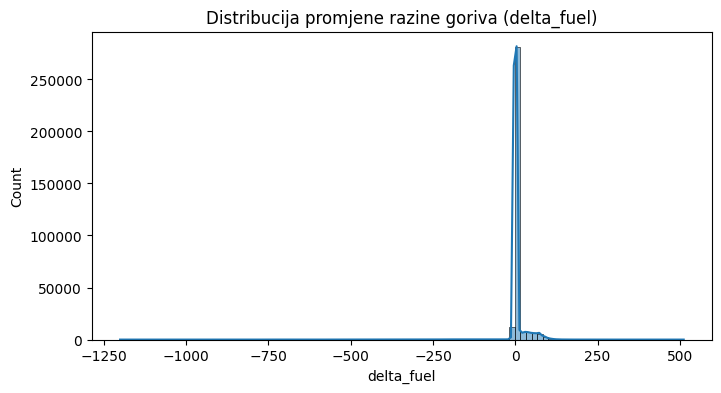

In [16]:
plt.figure(figsize=(8,4))
sns.histplot(df["delta_fuel"].dropna(), bins=100, kde=True)
plt.title("Distribucija promjene razine goriva (delta_fuel)")
plt.xlabel("delta_fuel")
plt.show()

Definicija labela: Normal / Refuel / Withdrawal

In [12]:
# pragovi u istim jedinicama kao fuel_lvl (provjeri skalu)
REFUEL_THR = 10    # koliko mora narasti da kažemo da je to Refuel
WITHDRAW_THR = -10 # koliko mora pasti da kažemo da je Withdrawal

def label_from_delta(df_row):
    d = df_row["delta_fuel"]
    if pd.isna(d):
        return "Normal"
    if d >= REFUEL_THR:
        return "Refuel"
    if d <= WITHDRAW_THR:
        return "Withdrawal"
    return "Normal"

df["label"] = df.apply(label_from_delta, axis=1)

df["label"].value_counts()

label
Normal        290808
Refuel         31820
Withdrawal      4792
Name: count, dtype: int64

Bar-graf raspodjele klasa (pokazuje debalans):

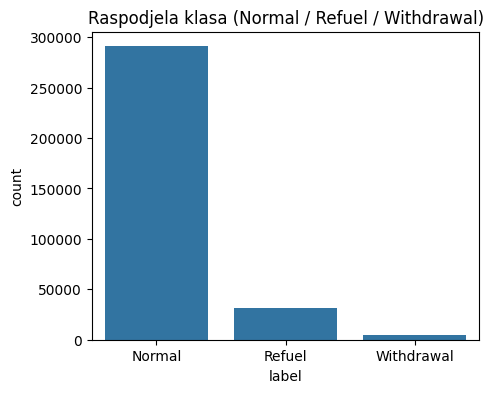

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="label")
plt.title("Raspodjela klasa (Normal / Refuel / Withdrawal)")
plt.show()

Vizualizacija vremena + labela za jedno vozilo

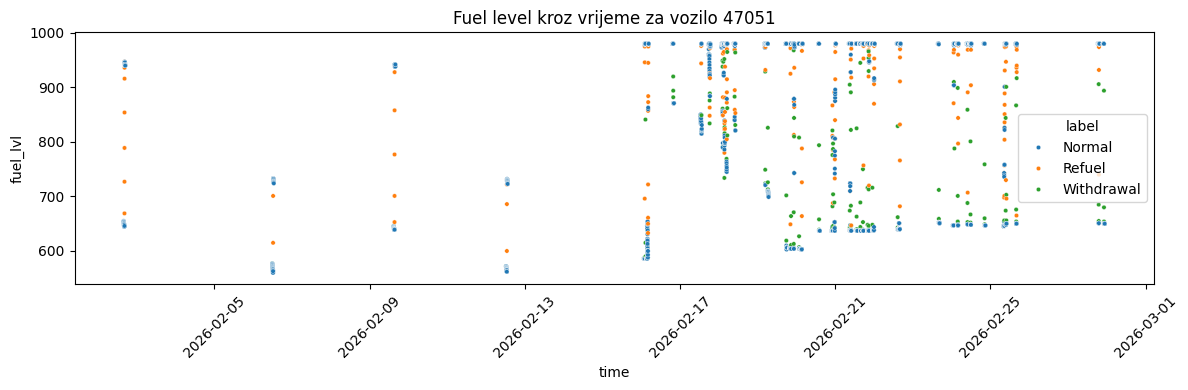

In [14]:
some_obj = df["obj_id"].value_counts().index[0]
df_obj = df[df["obj_id"] == some_obj]

plt.figure(figsize=(12,4))
sns.scatterplot(
    data=df_obj,
    x="time",
    y="fuel_lvl",
    hue="label",
    s=10
)
plt.title(f"Fuel level kroz vrijeme za vozilo {some_obj}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()